In [1]:
import sys
import os

# Dodanie katalogu głównego repo do ścieżki
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from pipeline.parametres_search import scan_turing_am, a_m_pairs
from pipeline.pattern_visualization import simulate_patterns, plot_patterns, save_as_npz, define_patterns, convert_to_csv

# Szybka teoria
Zakres parametrów:

* $a \in (0, \infty)$
* $m \in (0, \frac{a}{2})$
* $d_1 \in (d_2, \infty)$
* $d_2 \in (0, \infty)$

Założenia, z których korzystamy:

- $a^2 - 4m^2 \geq 0$ z $\Delta$ stanu stacjonarnego
- $d_1 \geq d_2$

# Test
W teście skorzystamy z przewidywania istnienia Turinga, więc musimy jedynie dokładnie przetestować $d_1$ i $d_2$

In [ ]:
# FIZYCZNE PARAMETRY
from pipeline.model_core import dimensional_to_dimensionless
A = [250, 500] # zakres; jednostkka kg * H20 * m^(-2) * rok^(-1)
L = 4 # rok^(-1)
J_tree = 0.002 # (kg * H20)^(-1)
J_grass = 0.003 # (kg * H20)^(-1)
M_tree = 0.18 # rok^(-1)
M_grass = 1.8 # rok^(-1)

# Brakuje: R, DW, DN
# R - pobor wody, czym większy, tym lepiej (zwiększa nam a)
# min dla drzew 2,0736
# min dla trawy 92,16
R_tree = 3 # kg * H20 * m^(-2) * rok^(-1) (kg dry mass)^(-2)
R_grass = 100 # kg * H20 * m^(-2) * rok^(-1) (kg dry mass)^(-2)

# Dw - dyfuzja wody (własne)
Dw = 10**5

# Dn - dyfuzja biomasy (własne)
Dn = 10**2

# Lx z ustaleń
Lx = 20

tryby = ["drzewa", "grass"]
tryb = tryby[1]

if tryb == "drzewa":
    J = J_tree
    M = M_tree
    R = R_tree
else:
    J = J_grass
    M = M_grass
    R = R_grass

a1, m, d1, d2 = dimensional_to_dimensionless(A[0], L, R, Dw, J, M, Dn, Lx)
a2, _, _, _ = dimensional_to_dimensionless(A[1], L, R, Dw, J, M, Dn, Lx)

print([a1, a2], m, d1, d2)

## Badanie parametru $d_1$
stałe $d_2 = 0.02$ i $d_1 \in [1,100]$

In [ ]:
d2 = 0.02
d1_vals = np.arange(1, 100, 1) # można zmienic co ile

## Badanie parametru $d_2$
stałe $d_1 = 100$ i $d_2 \in [0,1]$

In [ ]:
d1 = 100
d2_vals = np.arange(0.01, 1, 0.01) # można zmienic co ile i odkąd o ile >0

## Jak generować?
Parametr $d_1$

In [ ]:
# parametry stałe wszędzie (nie tykać!!!!)
Lx = 20
Ly = Lx
Nx = 100
Ny = Nx
mvals = np.arange(0.1, 1.51, 0.1)
avals = np.linspace(0.0, 5.0, 250)

# Parametr stały dla eksperymentu
d2 = 0.02

# podaj parametry
#d1_vals = np.arange(1, 100, 5) # np.arange(1, 100, co ile)
d1_vals = [5]

# Pętla
all_results = {}
a = []
m = []
d1v = []

for d1 in d1_vals:
    results = scan_turing_am(d1, d2, m_values=mvals, a_values=avals, k_min=0, k_max=20, n_k=1000)

    all_results[(d1, d2)] = results

    chosen = a_m_pairs(results, mvals)

    for row in chosen:
        m.extend([row["m"], row["m"]])
#        a.extend([row["a_max"], row["a_mean"]])
        a.extend([row["a_max"], row["a_median"]])
        d1v.extend([d1, d1])

d1_list = d1v
d2_list = [d2] * len(m)

if len(a) == len(m) == len(d1_list) == len(d2_list):
    print("ok")
else:
    raise ValueError("Wektory mają różne długości")

save_as_npz("plik", a, m, d1_list, d2_list)
define_patterns("plik")
convert_to_csv("plik")

Parametr $d_2$

In [2]:
import sys
import os

# Dodanie katalogu głównego repo do ścieżki
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from pipeline.parametres_search import scan_turing_am, a_m_pairs
from pipeline.pattern_visualization import simulate_patterns, plot_patterns, save_as_npz, define_patterns, convert_to_csv

# parametry stałe wszędzie (nie tykać!!!!)
Lx = 60
Ly = Lx
Nx = 100
Ny = Nx
#mvals = np.arange(0.1, 1.51, 0.1)
mvals = [0.45]
avals = np.linspace(0.0, 5.0, 250)

# Parametr stały dla eksperymentu
d1 = 100

# podaj parametry
#d2_vals = np.arange(0.1, 1, 0.01) # np.arrange(>0, 1, co ile)
d2_vals = [0.02]

# Pętla
all_results = {}
a, m, d2v = [], [], []

for d2 in d2_vals:
    results = scan_turing_am(d1, d2,m_values=mvals,a_values=avals,k_min=0, k_max=20, n_k=8000)

    all_results[(d1, d2)] = results
    chosen_ones = a_m_pairs(results, mvals)

    for row in chosen_ones:
        for aval in row["a_band"]:
            a.append(aval)
            m.append(row["m"])
            d2v.append(d2)
d2_list = d2v
d1_list = [d1] * len(m)

if len(a) == len(m) == len(d1_list) == len(d2_list):
    print("ok")
else:
    raise ValueError("Wektory mają różne długości")

print(len(a))


ok
5


krok=200, mean(v)=5.361265e-01, max(v)=6.671602e-01, var(v)=8.037095e-03
krok=400, mean(v)=2.374792e-01, max(v)=3.324693e-01, var(v)=3.365542e-03
krok=600, mean(v)=1.001101e-01, max(v)=1.491752e-01, var(v)=8.248293e-04
krok=800, mean(v)=4.112366e-02, max(v)=6.322894e-02, var(v)=1.643490e-04
krok=1000, mean(v)=1.670128e-02, max(v)=2.611345e-02, var(v)=3.001997e-05
krok=1200, mean(v)=6.751782e-03, max(v)=1.066528e-02, var(v)=5.277076e-06
krok=1400, mean(v)=2.724972e-03, max(v)=4.335704e-03, var(v)=9.107798e-07
krok=1600, mean(v)=1.099240e-03, max(v)=1.759219e-03, var(v)=1.556578e-07
krok=1800, mean(v)=4.434116e-04, max(v)=7.132534e-04, var(v)=2.644425e-08
krok=2000, mean(v)=1.788862e-04, max(v)=2.890928e-04, var(v)=4.474129e-09
krok=2200, mean(v)=7.218091e-05, max(v)=1.171586e-04, var(v)=7.546495e-10
krok=2400, mean(v)=2.913037e-05, max(v)=4.747750e-05, var(v)=1.269729e-10
krok=2600, mean(v)=1.175826e-05, max(v)=1.923944e-05, var(v)=2.132002e-11
krok=2800, mean(v)=4.746872e-06, max(v)=7.

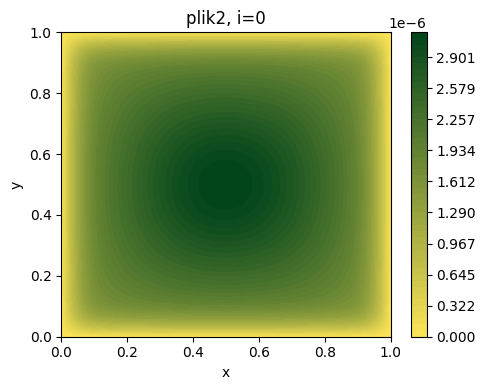

0. nic, 1. cętki, 2. pasy, 3. labirynty, 4. dziury, 5. coś (q=wyjdź):  0


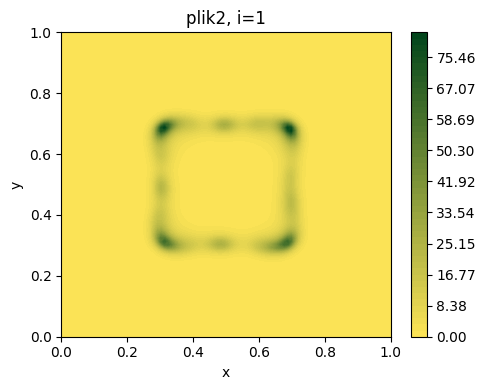

0. nic, 1. cętki, 2. pasy, 3. labirynty, 4. dziury, 5. coś (q=wyjdź):  2


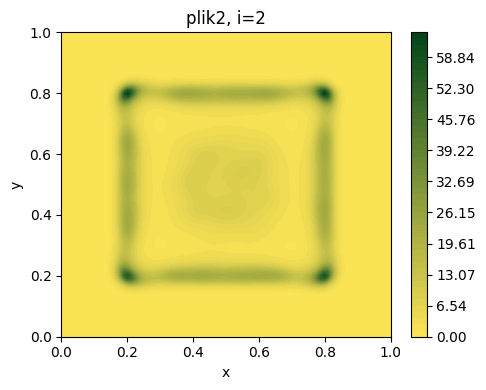

0. nic, 1. cętki, 2. pasy, 3. labirynty, 4. dziury, 5. coś (q=wyjdź):  2


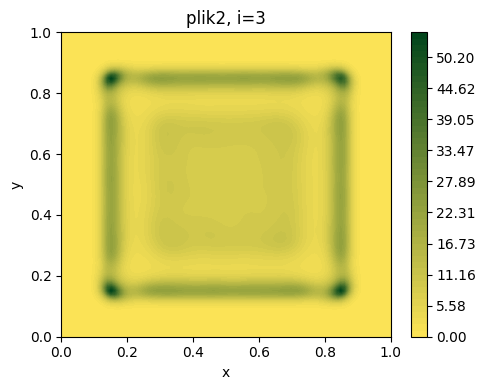

0. nic, 1. cętki, 2. pasy, 3. labirynty, 4. dziury, 5. coś (q=wyjdź):  2


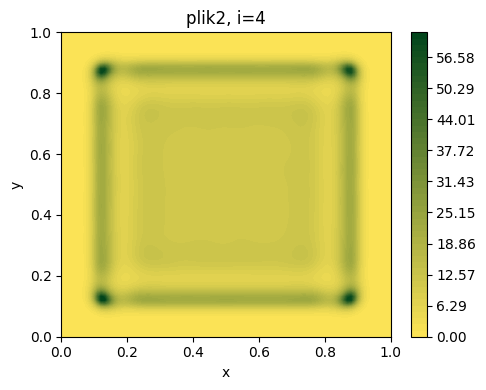

0. nic, 1. cętki, 2. pasy, 3. labirynty, 4. dziury, 5. coś (q=wyjdź):  2


Koniec. Etykiety ma 5/5 macierzy.
Plik zapisano do: wykresy_etykiety\plik2.npz


In [6]:
save_as_npz("plik2", a, m, d1_list, d2_list)
#convert_to_csv("plik")
define_patterns("plik2")

In [4]:
dane = np.load("wykresy_etykiety\plik2.npz")
atest = dane["a"]
mtest = dane["m"]
for i in range(len(mtest)):
    print(atest[i], mtest[i])

print(dane["patterns"])

0.9036 0.45
1.9277 0.45
2.9518 0.45
3.9759 0.45
5.0 0.45
[0 1 1 1 1]


In order to obtain Turing patterns under laboratory conditions, it is required that diffusion constants of the two
species have a sufficiently large ratio. (Suzuki)


krok=400, mean(v)=3.471549e+00, max(v)=4.186367e+00, var(v)=9.790269e-01
krok=800, mean(v)=3.262991e+00, max(v)=5.486483e+00, var(v)=2.287662e+00
krok=1200, mean(v)=3.227680e+00, max(v)=1.265872e+01, var(v)=3.970070e+00
krok=1600, mean(v)=3.283109e+00, max(v)=3.676011e+01, var(v)=9.880217e+00
Przerwano: NaN/inf w kroku 1843. Zwracam poprzedni udany zapis: 1600.


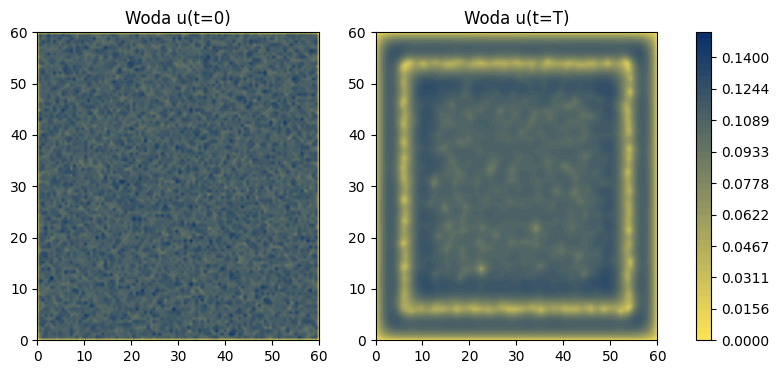

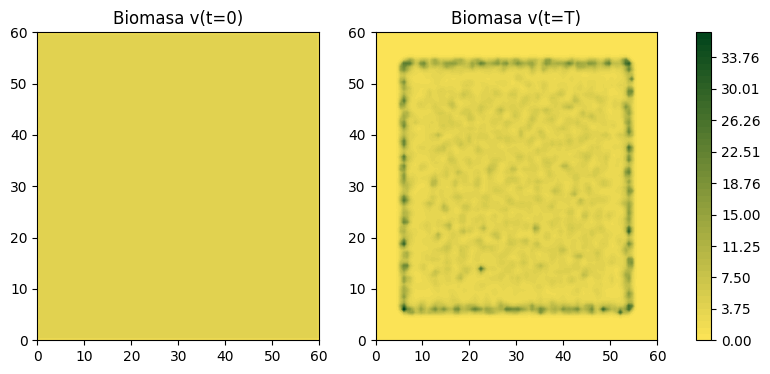

In [21]:
matierz=simulate_patterns(1.9277, 0.45, 100, 0.02, Lx, Ly, Nx, Ny, 8000, check_every=400, verbose=True)
plot_patterns(matierz)